# Cell-40
#### Payload type: for loop over noise_freq: per-iteration smooth_sig filtering + HoloViews plot assembly cell-40

In [1]:
%load_ext jumper_extension
%perfmonitor_fast_setup

[JUmPER]: NVIDIA drivers not available. NVIDIA GPU monitoring disabled.
[JUmPER]: ADLXPybind not available. AMD GPU monitoring disabled.


/home/h5/albu670g/jumper-ws/jumper_ipython_extension/jumper_extension/monitor/metrics/gpu/nvml.py:47: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml


[JUmPER]: Perfmonitor extension loaded
[JUmPER]: Enabled ipympl interactive plots
[JUmPER] Compiling native_c monitor binary (first use, one-time step)...
[JUmPER] Building C collector: /bin/make -C /home/h5/albu670g/jumper-ws/jumper_ipython_extension/jumper_extension/monitor/backends/native_c
[JUmPER] C collector compiled successfully.
[JUmPER] native_c monitor compiled successfully.
[JUmPER] Using native_c monitor (compiled C collector).
[JUmPER]: Performance monitoring started (PID: 243798, Interval: 1.0s)
[JUmPER]: Performance monitoring already running
[JUmPER]: Performance reports enabled for each cell (level: process, interval: 1.0, format: html)
[JUmPER]: Fast setup complete! Ready for interactive analysis.


In [2]:
%%capture
%load_ext autoreload
%autoreload 2
import itertools as itt
import os
import sys

import holoviews as hv
import numpy as np
import xarray as xr
from dask.distributed import Client, LocalCluster
from holoviews.operation.datashader import datashade, regrid
from holoviews.util import Dynamic
from IPython import get_ipython
from IPython.display import display

from minian.data import fetch

memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.0005034285752140199), 'cpu': np.float64(0.0408931938095238), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []
memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.0005034285752140199), 'cpu': np.float64(0.0408931938095238), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),4.09,1.25,16.00,-
Memory (GB),0.25,0.20,0.30,503.18


In [3]:
# Set up Initial Basic Parameters#
# `dpath` is the folder containing the videos to process. By default we
# fetch the bundled demo recording.
# To analyze your own data, set `dpath` to your own
# video folder instead.
dpath = os.fspath(fetch("pipeline-demo"))
minian_ds_path = os.path.join(dpath, "minian")
intpath = "./minian_intermediate"
subset = dict(frame=slice(0, None))
subset_mc = None
# get_ipython() is None in a bare interpreter, so benchmark replays and plain
# script runs skip the viewer/plot work while a live kernel keeps it.
interactive = (
    os.getenv("MINIAN_INTERACTIVE", "True").lower() == "true"
    and get_ipython() is not None
)
output_size = 100
n_workers = int(os.getenv("MINIAN_NWORKERS", 4))
# memory_limit is per-worker, not pooled across workers. Each worker is a
# separate process; modern dask kills any worker that exceeds this. Default
# "4GB" targets a 16GB laptop with 4 workers; lower it on smaller machines.
memory_limit = os.getenv("MINIAN_MEM_LIMIT", "4GB")
# rechunk_mem_limit caps RAM per rechunker task in save_minian's on-disk
# rechunk step (used by save_minian calls that pass chunks=), independent of
# the per-worker memory_limit above. rechunker plans its intermediate grid
# against this value, so a small limit forces many tiny copy tasks on large
# arrays like Y_hw_chk. Keep it at or below the per-worker memory_limit.
rechunk_mem_limit = os.getenv("MINIAN_RECHUNK_MEM_LIMIT", "1GB")
param_save_minian = {
    "dpath": minian_ds_path,
    "meta_dict": dict(session=-1, animal=-2),
    "overwrite": True,
}

# Pre-processing Parameters#
param_load_videos = {
    "pattern": os.getenv("MINIAN_FILE_PATTERN", r"msCam[0-9]+\.avi$"),
    "dtype": np.uint8,
    "downsample": dict(frame=1, height=1, width=1),
    "downsample_strategy": "subset",
}
param_denoise = {"method": "median", "ksize": 7}
param_background_removal = {"method": "tophat", "wnd": 15}

# Motion Correction Parameters#
subset_mc = None
param_estimate_motion = {"dim": "frame"}

# Initialization Parameters#
param_seeds_init = {
    "wnd_size": 1000,
    "method": "rolling",
    "stp_size": 500,
    "max_wnd": 15,
    "diff_thres": 3,
}
param_pnr_refine = {"noise_freq": 0.06, "thres": 1}
param_ks_refine = {"sig": 0.05}
# `chunk` is the target partition size handed to minian.cnmf.spatial_partition.
# Larger = fewer, bigger dask tasks; smaller = more, lighter tasks.
# Library default is 600.
param_seeds_merge = {"thres_dist": 10, "thres_corr": 0.8, "noise_freq": 0.06, "chunk": 600}
param_initialize = {"thres_corr": 0.8, "wnd": 10, "noise_freq": 0.06, "chunk": 600}
param_init_merge = {"thres_corr": 0.8, "chunk": 600}

# CNMF Parameters#
param_get_noise = {"noise_range": (0.06, 0.5)}
param_first_spatial = {
    "dl_wnd": 10,
    "sparse_penal": 0.01,
    "size_thres": (25, None),
}
param_first_temporal = {
    "noise_freq": 0.06,
    "sparse_penal": 1,
    "p": 1,
    "add_lag": 20,
    "jac_thres": 0.2,
}
param_first_merge = {"thres_corr": 0.8, "chunk": 600}
param_second_spatial = {
    "dl_wnd": 10,
    "sparse_penal": 0.01,
    "size_thres": (25, None),
}
param_second_temporal = {
    "noise_freq": 0.06,
    "sparse_penal": 1,
    "p": 1,
    "add_lag": 20,
    "jac_thres": 0.4,
}

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MINIAN_INTERMEDIATE"] = intpath

memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.0006090802496124647), 'cpu': np.float64(0.05874922666666667), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),5.87,4.50,7.37,-
Memory (GB),0.31,0.31,0.31,503.18


In [4]:
%%capture
from minian.cnmf import (
    compute_AtC,
    compute_trace,
    get_noise_fft,
    smooth_sig,
    unit_merge,
    update_spatial,
    update_temporal,
    update_background,
)
from minian.initialization import (
    gmm_refine,
    initA,
    initC,
    intensity_refine,
    ks_refine,
    pnr_refine,
    seeds_init,
    seeds_merge,
)
from minian.motion_correction import apply_transform, estimate_motion
from minian.preprocessing import denoise, remove_background
from minian.utilities import (
    TaskAnnotation,
    get_optimal_chk,
    load_videos,
    open_minian,
    save_minian,
)
from minian.visualization import (
    CNMFViewer,
    VArrayViewer,
    generate_videos,
    visualize_gmm_fit,
    visualize_motion,
    visualize_preprocess,
    visualize_seeds,
    visualize_seeds_merge_partition,
    visualize_spatial_update,
    visualize_temporal_update,
    write_video,
)

memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.0007975186902211029), 'cpu': np.float64(0.04689390484848485), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []
memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.0007975186902211029), 'cpu': np.float64(0.04689390484848485), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),4.69,2.00,13.62,-
Memory (GB),0.40,0.31,0.50,503.18


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
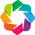

memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.0010461057673198458), 'cpu': np.float64(0.065208295), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),6.52,2.62,13.50,-
Memory (GB),0.53,0.51,0.54,503.18


In [5]:
dpath = os.path.abspath(dpath)
# hv.extension resolves to notebook_extension inside a live kernel and to the
# plain backend loader in a bare interpreter, so benchmark replays survive it.
hv.extension("bokeh")

In [6]:
# Match older dask (pre-2022.10) memory semantics: when a worker exceeds
# memory_limit, spill data to disk instead of terminating the worker process.
# Modern dask kills workers at 95% of memory_limit by default, which collapses
# the cluster on bulk operations (update_background, write_video over the full
# residual movie). Spilling is slower than killing-and-retrying but always
# finishes.
import dask
dask.config.set({"distributed.worker.memory.terminate": False})
cluster = LocalCluster(
    n_workers=n_workers,
    memory_limit=memory_limit,
    resources={"MEM": 1},
    threads_per_worker=2,
    dashboard_address=":8787",
)
annt_plugin = TaskAnnotation()
cluster.scheduler.add_plugin(annt_plugin)
client = Client(cluster)

/data/horse/ws/albu670g-jumper/kernels/jumper-romeo/lib/python3.12/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/data/horse/ws/albu670g-jumper/kernels/jumper-romeo/lib/python3.12/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/data/horse/ws/albu670g-jumper/kernels/jumper-romeo/lib/python3.12/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pyn

memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.0010809263086768155), 'cpu': np.float64(0.03750075), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


/data/horse/ws/albu670g-jumper/kernels/jumper-romeo/lib/python3.12/site-packages/dask/config.py:835: FutureWarning: Dask configuration key 'distributed.scheduler.transition-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),3.75,1.62,6.63,-
Memory (GB),0.54,0.54,0.54,503.18


In [7]:
param_load_videos

{'pattern': 'msCam[0-9]+\\.avi$',
 'dtype': numpy.uint8,
 'downsample': {'frame': 1, 'height': 1, 'width': 1},
 'downsample_strategy': 'subset'}

memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.0010809263086768155), 'cpu': np.float64(0.03750075), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),3.75,1.62,6.63,-
Memory (GB),0.54,0.54,0.54,503.18


In [8]:
varr = load_videos(dpath, **param_load_videos)
chk, _ = get_optimal_chk(varr, dtype=float)

loading 10 videos in folder /data/horse/ws/albu670g-jumper/minian-cache/pipeline-demo
memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.0010809263086768155), 'cpu': np.float64(0.03750075), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),3.75,1.62,6.63,-
Memory (GB),0.54,0.54,0.54,503.18


In [9]:
varr = save_minian(
    varr.chunk({"frame": chk["frame"], "height": -1, "width": -1}).rename("varr"),
    intpath,
    overwrite=True,
)

ffmpeg version 7.0.2 Copyright (c) 2000-2024 the FFmpeg developers
  built with gcc 13.3.0 (GCC)
  configuration: --prefix=/software/rome/r25.06/FFmpeg/7.0.2-GCCcore-13.3.0 --enable-pic --enable-shared --enable-gpl --enable-version3 --enable-nonfree --cc=gcc --cxx=g++ --enable-libx264 --enable-libx265 --enable-libmp3lame --enable-libfreetype --enable-fontconfig --enable-libfribidi --enable-sdl2 --disable-htmlpages
  libavutil      59.  8.100 / 59.  8.100
  libavcodec     61.  3.100 / 61.  3.100
  libavformat    61.  1.100 / 61.  1.100
  libavdevice    61.  1.100 / 61.  1.100
  libavfilter    10.  1.100 / 10.  1.100
  libswscale      8.  1.100 /  8.  1.100
  libswresample   5.  1.100 /  5.  1.100
  libpostproc    58.  1.100 / 58.  1.100
ffmpeg version 7.0.2 Copyright (c) 2000-2024 the FFmpeg developers
  built with gcc 13.3.0 (GCC)
  configuration: --prefix=/software/rome/r25.06/FFmpeg/7.0.2-GCCcore-13.3.0 --enable-pic --enable-shared --enable-gpl --enable-version3 --enable-nonfree --cc

memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.0010905818991215866), 'cpu': np.float64(0.02333333222222222), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),2.33,1.50,5.25,-
Memory (GB),0.55,0.55,0.55,503.18


In [10]:
# %perfmonitor_ai_review --benchmark --replay-mode fork

In [11]:
varr

<xarray.DataArray 'varr' (frame: 2000, height: 480, width: 752)> Size: 722MB
dask.array<from-zarr, shape=(2000, 480, 752), dtype=uint8, chunksize=(92, 480, 752), chunktype=numpy.ndarray>
Coordinates:
  * frame    (frame) int64 16kB 0 1 2 3 4 5 6 ... 1994 1995 1996 1997 1998 1999
  * height   (height) int64 4kB 0 1 2 3 4 5 6 7 ... 473 474 475 476 477 478 479
  * width    (width) int64 6kB 0 1 2 3 4 5 6 7 ... 745 746 747 748 749 750 751

memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.0010905818991215866), 'cpu': np.float64(0.02333333222222222), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),2.33,1.50,5.25,-
Memory (GB),0.55,0.55,0.55,503.18


In [12]:
hv.output(size=output_size)
if interactive:
    vaviewer = VArrayViewer(varr, framerate=5, summary=["mean", "max"])
    display(vaviewer.show())

computing summary


Column
    [0] WidgetBox
        [0] Button(button_type='primary', color='primary', height=30, label='Update Mask', name='Update Mask', sizing_mode='fixed', width=100)
        [1] Player(end=1999, height=90, interval=10, sizing_mode='fixed', width=650)
    [1] HoloViews(Layout)

memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.001112943583570397), 'cpu': np.float64(0.0360120380952381), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),3.60,1.37,13.13,-
Memory (GB),0.56,0.55,0.62,503.18


In [13]:
if interactive:
    try:
        subset_mc = list(vaviewer.mask.values())[0]
    except IndexError:
        pass

memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.001112943583570397), 'cpu': np.float64(0.0360120380952381), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),3.60,1.37,13.13,-
Memory (GB),0.56,0.55,0.62,503.18


In [14]:
varr_ref = varr.sel(subset)

memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.001112943583570397), 'cpu': np.float64(0.0360120380952381), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),3.60,1.37,13.13,-
Memory (GB),0.56,0.55,0.62,503.18


In [15]:
%%time
varr_min = varr_ref.min("frame").compute()
varr_ref = varr_ref - varr_min

CPU times: user 94.4 ms, sys: 13.7 ms, total: 108 ms
Wall time: 291 ms
memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.001112943583570397), 'cpu': np.float64(0.0360120380952381), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),3.60,1.37,13.13,-
Memory (GB),0.56,0.55,0.62,503.18


In [16]:
hv.output(size=int(output_size * 0.7))
if interactive:
    vaviewer = VArrayViewer(
        [varr.rename("original"), varr_ref.rename("glow_removed")],
        framerate=5,
        summary=None,
        layout=True,
    )
    display(vaviewer.show())

computing summary


/data/horse/ws/albu670g-jumper/kernels/jumper-romeo/lib/python3.12/site-packages/datashader/transfer_functions/__init__.py:580: RuntimeWarning: All-NaN slice encountered
  baseline = module.nanmin(color_data) if color_baseline is None else color_baseline
/data/horse/ws/albu670g-jumper/kernels/jumper-romeo/lib/python3.12/site-packages/datashader/transfer_functions/__init__.py:580: RuntimeWarning: All-NaN slice encountered
  baseline = module.nanmin(color_data) if color_baseline is None else color_baseline


Column
    [0] WidgetBox
        [0] Button(button_type='primary', color='primary', height=30, label='Update Mask', name='Update Mask', sizing_mode='fixed', width=100)
        [1] Player(end=1999, height=90, interval=10, sizing_mode='fixed', width=650)
    [1] HoloViews(Layout)

memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.0012858663897611193), 'cpu': np.float64(0.12031283250000001), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),12.03,10.25,13.63,-
Memory (GB),0.65,0.64,0.65,503.18


In [17]:
param_denoise

{'method': 'median', 'ksize': 7}

memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.0012882785484319727), 'cpu': np.float64(0.12200012400000002), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),12.20,10.25,13.63,-
Memory (GB),0.65,0.64,0.65,503.18


In [18]:
hv.output(size=int(output_size * 0.6))
if interactive:
    display(
        visualize_preprocess(
            varr_ref.isel(frame=0).compute(),
            denoise,
            method=["median"],
            ksize=[5, 7, 9],
        )
    )

:Layout
   .Image.Before        :Image   [width,height]   (varr)
   .DynamicMap.Before   :DynamicMap   []
      :RGB   [width,height]   (R,G,B,A)
   .DynamicMap.After.I  :DynamicMap   [method,ksize]
      :Image   [width,height]   (varr_denoised)
   .DynamicMap.After.II :DynamicMap   [method,ksize]
      :RGB   [width,height]   (R,G,B,A)

memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.0013904880957112764), 'cpu': np.float64(0.123999966), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),12.40,6.75,14.00,-
Memory (GB),0.70,0.66,0.72,503.18


In [19]:
varr_ref = denoise(varr_ref, **param_denoise)

memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.0013904880957112764), 'cpu': np.float64(0.123999966), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),12.40,6.75,14.00,-
Memory (GB),0.70,0.66,0.72,503.18


In [20]:
param_background_removal

{'method': 'tophat', 'wnd': 15}

memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.0013904880957112764), 'cpu': np.float64(0.123999966), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),12.40,6.75,14.00,-
Memory (GB),0.70,0.66,0.72,503.18


In [21]:
hv.output(size=int(output_size * 0.6))
if interactive:
    display(
        visualize_preprocess(
            varr_ref.isel(frame=0).compute(),
            remove_background,
            method=["tophat"],
            wnd=[10, 15, 20],
        )
    )

:Layout
   .Image.Before        :Image   [width,height]   (varr_denoised)
   .DynamicMap.Before   :DynamicMap   []
      :RGB   [width,height]   (R,G,B,A)
   .DynamicMap.After.I  :DynamicMap   [method,wnd]
      :Image   [width,height]   (varr_denoised_subtracted)
   .DynamicMap.After.II :DynamicMap   [method,wnd]
      :RGB   [width,height]   (R,G,B,A)

memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.001464306510592631), 'cpu': np.float64(0.0809374475), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),8.09,2.00,14.00,-
Memory (GB),0.74,0.73,0.75,503.18


In [22]:
varr_ref = remove_background(varr_ref, **param_background_removal)

memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.001464306510592631), 'cpu': np.float64(0.0809374475), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),8.09,2.00,14.00,-
Memory (GB),0.74,0.73,0.75,503.18


In [23]:
%%time
varr_ref = save_minian(varr_ref.rename("varr_ref"), dpath=intpath, overwrite=True)

CPU times: user 481 ms, sys: 160 ms, total: 641 ms
Wall time: 10.4 s
memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.001515104535156405), 'cpu': np.float64(0.0240001), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),2.40,1.62,5.63,-
Memory (GB),0.76,0.76,0.76,503.18


In [24]:
param_estimate_motion

{'dim': 'frame'}

memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.001515104535156405), 'cpu': np.float64(0.0240001), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),2.40,1.62,5.63,-
Memory (GB),0.76,0.76,0.76,503.18


In [25]:
motion = estimate_motion(varr_ref.sel(subset_mc), **param_estimate_motion)

memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.001515104535156405), 'cpu': np.float64(0.0240001), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),2.40,1.62,5.63,-
Memory (GB),0.76,0.76,0.76,503.18


In [26]:
# %perfmonitor_ai_review --benchmark --replay-mode fork

In [27]:
param_save_minian

{'dpath': '/data/horse/ws/albu670g-jumper/minian-cache/pipeline-demo/minian',
 'meta_dict': {'session': -1, 'animal': -2},
 'overwrite': True}

memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.001515104535156405), 'cpu': np.float64(0.0240001), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),2.40,1.62,5.63,-
Memory (GB),0.76,0.76,0.76,503.18


In [28]:
%%time
motion = save_minian(
    motion.rename("motion").chunk({"frame": chk["frame"]}), **param_save_minian
)

CPU times: user 1.77 s, sys: 630 ms, total: 2.4 s
Wall time: 33.1 s
memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.0015188058493436289), 'cpu': np.float64(0.02518940606060606), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),2.52,1.63,7.88,-
Memory (GB),0.76,0.76,0.76,503.18


In [29]:
hv.output(size=output_size)
visualize_motion(motion)

:NdOverlay   [Element]
   :Curve   [frame]   (motion)

memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.001522899360069955), 'cpu': np.float64(0.088126055), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),8.81,6.38,11.25,-
Memory (GB),0.77,0.77,0.77,503.18


In [30]:
Y = apply_transform(varr_ref, motion, fill=0)

memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.001522899360069955), 'cpu': np.float64(0.088126055), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),8.81,6.38,11.25,-
Memory (GB),0.77,0.77,0.77,503.18


In [31]:
%%time
Y_fm_chk = save_minian(Y.astype(np.float32).rename("Y_fm_chk"), intpath, overwrite=True)
Y_hw_chk = save_minian(
    Y_fm_chk.rename("Y_hw_chk"),
    intpath,
    overwrite=True,
    mem_limit=rechunk_mem_limit, chunks={"frame": -1, "height": chk["height"], "width": chk["width"]},
)

CPU times: user 2.56 s, sys: 799 ms, total: 3.36 s
Wall time: 1min 3s
memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.0015239213290969434), 'cpu': np.float64(0.0196288865625), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),1.96,1.37,10.37,-
Memory (GB),0.77,0.77,0.77,503.18


In [32]:
hv.output(size=int(output_size * 0.7))
if interactive:
    vaviewer = VArrayViewer(
        [varr_ref.rename("before_mc"), Y_fm_chk.rename("after_mc")],
        framerate=5,
        summary=None,
        layout=True,
    )
    display(vaviewer.show())

computing summary


/data/horse/ws/albu670g-jumper/kernels/jumper-romeo/lib/python3.12/site-packages/datashader/transfer_functions/__init__.py:580: RuntimeWarning: All-NaN slice encountered
  baseline = module.nanmin(color_data) if color_baseline is None else color_baseline
/data/horse/ws/albu670g-jumper/kernels/jumper-romeo/lib/python3.12/site-packages/datashader/transfer_functions/__init__.py:580: RuntimeWarning: All-NaN slice encountered
  baseline = module.nanmin(color_data) if color_baseline is None else color_baseline


Column
    [0] WidgetBox
        [0] Button(button_type='primary', color='primary', height=30, label='Update Mask', name='Update Mask', sizing_mode='fixed', width=100)
        [1] Player(end=1999, height=90, interval=10, sizing_mode='fixed', width=650)
    [1] HoloViews(Layout)

memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.0015305545066709061), 'cpu': np.float64(0.052291351666666666), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),5.23,1.62,13.87,-
Memory (GB),0.77,0.77,0.79,503.18


In [33]:
im_opts = dict(
    frame_width=500,
    aspect=varr_ref.sizes["width"] / varr_ref.sizes["height"],
    cmap="Viridis",
    colorbar=True,
)
(
    regrid(
        hv.Image(
            varr_ref.max("frame").compute().astype(np.float32),
            ["width", "height"],
            label="before_mc",
        ).opts(**im_opts)
    )
    + regrid(
        hv.Image(
            Y_hw_chk.max("frame").compute().astype(np.float32),
            ["width", "height"],
            label="after_mc",
        ).opts(**im_opts)
    )
)

:Layout
   .DynamicMap.I  :DynamicMap   []
      :Image   [width,height]   (varr_ref)
   .DynamicMap.II :DynamicMap   []
      :Image   [width,height]   (Y_hw_chk)

memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.0015664430472196829), 'cpu': np.float64(0.028359204374999995), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),2.84,1.50,12.50,-
Memory (GB),0.79,0.79,0.80,503.18


In [34]:
%%time
vid_arr = xr.concat([varr_ref, Y_fm_chk], "width").chunk({"width": -1})
write_video(vid_arr, "minian_mc.mp4", dpath)

ffmpeg version 7.0.2 Copyright (c) 2000-2024 the FFmpeg developers
  built with gcc 13.3.0 (GCC)
  configuration: --prefix=/software/rome/r25.06/FFmpeg/7.0.2-GCCcore-13.3.0 --enable-pic --enable-shared --enable-gpl --enable-version3 --enable-nonfree --cc=gcc --cxx=g++ --enable-libx264 --enable-libx265 --enable-libmp3lame --enable-libfreetype --enable-fontconfig --enable-libfribidi --enable-sdl2 --disable-htmlpages
  libavutil      59.  8.100 / 59.  8.100
  libavcodec     61.  3.100 / 61.  3.100
  libavformat    61.  1.100 / 61.  1.100
  libavdevice    61.  1.100 / 61.  1.100
  libavfilter    10.  1.100 / 10.  1.100
  libswscale      8.  1.100 /  8.  1.100
  libswresample   5.  1.100 /  5.  1.100
  libpostproc    58.  1.100 / 58.  1.100
Input #0, rawvideo, from 'pipe:':
  Duration: N/A, start: 0.000000, bitrate: 144384 kb/s
  Stream #0:0: Video: rawvideo (Y800 / 0x30303859), gray, 1504x480, 144384 kb/s, 25 tbr, 25 tbn
Stream mapping:
  Stream #0:0 (rawvideo) -> pad:default
  pad:default

CPU times: user 2.61 s, sys: 2.13 s, total: 4.74 s
Wall time: 29.7 s


[out#0/mp4 @ 0xe0a740] video:114286KiB audio:0KiB subtitle:0KiB other streams:0KiB global headers:0KiB muxing overhead: 0.009881%
frame= 2400 fps=150 q=-1.0 Lsize=  114298KiB time=00:01:20.00 bitrate=11704.1kbits/s dup=400 drop=0 speed=4.99x    
[libx264 @ 0xe0b900] frame I:10    Avg QP:16.80  size: 93211
[libx264 @ 0xe0b900] frame P:2390  Avg QP:19.80  size: 48576
[libx264 @ 0xe0b900] mb I  I16..4: 100.0%  0.0%  0.0%
[libx264 @ 0xe0b900] mb P  I16..4: 49.9%  0.0%  0.0%  P16..4: 45.4%  0.0%  0.0%  0.0%  0.0%    skip: 4.7%
[libx264 @ 0xe0b900] coded y,uvDC,uvAC intra: 98.0% 0.0% 0.0% inter: 74.7% 0.0% 0.0%
[libx264 @ 0xe0b900] i16 v,h,dc,p: 21% 22% 40% 17%
[libx264 @ 0xe0b900] i8c dc,h,v,p: 100%  0%  0%  0%
[libx264 @ 0xe0b900] kb/s:11702.86


'/data/horse/ws/albu670g-jumper/minian-cache/pipeline-demo/minian_mc.mp4'

memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.0017150100030472856), 'cpu': np.float64(0.14254192033333335), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),14.25,1.75,35.00,-
Memory (GB),0.86,0.80,0.98,503.18


In [35]:
max_proj = save_minian(
    Y_fm_chk.max("frame").rename("max_proj"), **param_save_minian
).compute()

memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.0016086430303271194), 'cpu': np.float64(0.06749831), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),6.75,6.75,6.75,-
Memory (GB),0.81,0.81,0.81,503.18


In [36]:
param_seeds_init

{'wnd_size': 1000,
 'method': 'rolling',
 'stp_size': 500,
 'max_wnd': 15,
 'diff_thres': 3}

memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.0016086430303271194), 'cpu': np.float64(0.06749831), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),6.75,6.75,6.75,-
Memory (GB),0.81,0.81,0.81,503.18


In [37]:
%%time
seeds = seeds_init(Y_fm_chk, **param_seeds_init)

constructing chunks
computing max projections
calculating local maximum
CPU times: user 540 ms, sys: 139 ms, total: 679 ms
Wall time: 4.42 s
memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.0016103175801899915), 'cpu': np.float64(0.038500573999999996), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),3.85,1.87,7.75,-
Memory (GB),0.81,0.81,0.81,503.18


In [38]:
seeds.head()

,height,width,seeds
0,0,326,1.0
1,2,384,1.0
2,2,386,2.0
3,6,258,2.0
4,7,386,1.0


memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.0016103175801899915), 'cpu': np.float64(0.038500573999999996), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),3.85,1.87,7.75,-
Memory (GB),0.81,0.81,0.81,503.18


In [39]:
hv.output(size=output_size)
visualize_seeds(max_proj, seeds)

:Overlay
   .Image.I  :Image   [width,height]   (max_proj)
   .Points.I :Points   [width,height]   (seeds)

memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.0016103175801899915), 'cpu': np.float64(0.038500573999999996), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),3.85,1.87,7.75,-
Memory (GB),0.81,0.81,0.81,503.18


In [40]:
noise_freq_list = [0.005, 0.01, 0.02, 0.06, 0.1, 0.2, 0.3, 0.45, 0.6, 0.8]
example_seeds = seeds.sample(6, axis="rows", random_state=0)
example_trace = Y_hw_chk.sel(
    height=example_seeds["height"].to_xarray(),
    width=example_seeds["width"].to_xarray(),
).rename(**{"index": "seed"})
smooth_dict = dict()
for freq in noise_freq_list:
    trace_smth_low = smooth_sig(example_trace, freq)
    trace_smth_high = smooth_sig(example_trace, freq, btype="high")
    trace_smth_low = trace_smth_low.compute()
    trace_smth_high = trace_smth_high.compute()
    hv_trace = hv.HoloMap(
        {
            "signal": (
                hv.Dataset(trace_smth_low)
                .to(hv.Curve, kdims=["frame"])
                .opts(frame_width=300, aspect=2, ylabel="Signal (A.U.)")
            ),
            "noise": (
                hv.Dataset(trace_smth_high)
                .to(hv.Curve, kdims=["frame"])
                .opts(frame_width=300, aspect=2, ylabel="Signal (A.U.)")
            ),
        },
        kdims="trace",
    ).collate()
    smooth_dict[freq] = hv_trace

memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.0016355470635330722), 'cpu': np.float64(0.045892874285714286), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),4.59,1.62,11.88,-
Memory (GB),0.82,0.82,0.82,503.18


In [41]:
%perfmonitor_ai_review --benchmark --replay-mode full

memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.0016355470635330722), 'cpu': np.float64(0.045892874285714286), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []
[JUmPER]: benchmark check validate_syntax for 'python': active
[JUmPER]: benchmark check run for 'python': active
[JUmPER]: benchmarking 3 suggestion(s) against cell 38; each replays 38 preceding cell(s) 3 time(s). This can take a while.
[JUmPER]: benchmark: measuring the original cell (run 1/3)
[JUmPER]: benchmark: measuring the original cell (run 2/3)
[JUmPER]: benchmark: measuring the original cell (run 3/3)
[JUmPER]: benchmark: the original cell takes 4.198507s; ~19 min to go
[JUmPER]: benchmark: option 1/3 (run 1/3)
[JUmPER]: benchmark: option 1/3 failed (  warnings.warn('resource_tracker: There appear to be %d '); repairing (1/3)
[JUmPER]: benchmark: option 2/3 (run 1/3)
[JUmPER]: benchmark: option 2/3 failed (  warnings.warn('resource_tracker: There appear to be %d '); repairing (1/3)
[JU

# Cell-77
#### Payload type: for loop over parameter grid: update_temporal deconvolution on persisted dask arrays cell-77

/data/horse/ws/albu670g-jumper/kernels/jumper-romeo/lib/python3.12/site-packages/dask/config.py:835: FutureWarning: Dask configuration key 'distributed.scheduler.transition-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
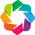

/data/horse/ws/albu670g-jumper/kernels/jumper-romeo/lib/python3.12/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/data/horse/ws/albu670g-jumper/kernels/jumper-romeo/lib/python3.12/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/data/horse/ws/albu670g-jumper/kernels/jumper-romeo/lib/python3.12/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pyn

memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.0008164027452071493), 'cpu': np.float64(0.12608201466666666), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),12.61,1.63,23.75,-
Memory (GB),0.41,0.25,0.53,503.18


2026-09-03 14:51:52,297 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle ac53f70db14c496e01977581527dfce4 initialized by task ('rechunk-merge-rechunk-transfer-1140576821c6c7f0daf58a43124a169b', 0, 0, 0, 0) executed on worker tcp://127.0.0.1:36909
2026-09-03 14:51:52,768 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle ac53f70db14c496e01977581527dfce4 deactivated due to stimulus 'task-finished-1788439912.765516'
2026-09-03 14:51:59,419 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle ac53f70db14c496e01977581527dfce4 initialized by task ('rechunk-merge-rechunk-transfer-1140576821c6c7f0daf58a43124a169b', 0, 0, 0, 0) executed on worker tcp://127.0.0.1:36909
2026-09-03 14:51:59,467 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle ac53f70db14c496e01977581527dfce4 deactivated due to stimulus 'task-finished-1788439919.4657454'
2026-09-03 14:51:59,807 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle ac53f70db14c496e01977581527dfce4 initiali

In [2]:
# Setup dependencies for temporal update benchmark
import os
import itertools as itt
import numpy as np
import holoviews as hv
from dask.distributed import Client, get_client
from minian.cnmf import compute_trace, update_temporal
from minian.visualization import visualize_temporal_update
from minian.utilities import open_minian

# Load HoloViews plotting extension
hv.extension("bokeh")

# Ensure Dask client/cluster is available
try:
    client = get_client()
except ValueError:
    from dask.distributed import LocalCluster
    cluster = LocalCluster()
    client = Client(cluster)

# Set thread environment variables and intermediate path required by Minian
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

intpath = os.path.abspath("./minian_intermediate")
os.environ["MINIAN_INTERMEDIATE"] = intpath

# Load precomputed Zarr arrays from disk
varr_dict = open_minian(intpath, return_dict=True)
A = varr_dict["A"]
C_chk = varr_dict["C_chk"]
b = varr_dict["b"]
f = varr_dict["f"]
Y_fm_chk = varr_dict["Y_fm_chk"]

# Prepare a subset of 10 units for testing
units = np.random.default_rng(0).choice(A.coords["unit_id"], 10, replace=False)
units.sort()
A_sub = A.sel(unit_id=units).persist()
C_sub = C_chk.sel(unit_id=units).persist()


In [3]:
p_ls = [1]
sprs_ls = [0.1, 0.5, 1, 2]
add_ls = [20]
noise_ls = [0.06]
YA_dict, C_dict, S_dict, g_dict, sig_dict, A_dict = [dict() for _ in range(6)]
YrA = (
    compute_trace(Y_fm_chk, A_sub, b, C_sub, f)
    .persist()
    .chunk({"unit_id": 1, "frame": -1})
)
for cur_p, cur_sprs, cur_add, cur_noise in itt.product(
    p_ls, sprs_ls, add_ls, noise_ls
):
    ks = (cur_p, cur_sprs, cur_add, cur_noise)
    print(
        f"p:{cur_p}, sparse penalty:{cur_sprs}, additional lag:{cur_add}, noise frequency:{cur_noise}"
    )
    cur_C, cur_S, cur_b0, cur_c0, cur_g, cur_mask = update_temporal(
        A_sub,
        C_sub,
        YrA=YrA,
        sparse_penal=cur_sprs,
        p=cur_p,
        use_smooth=True,
        add_lag=cur_add,
        noise_freq=cur_noise,
    )
    YA_dict[ks], C_dict[ks], S_dict[ks], g_dict[ks], sig_dict[ks], A_dict[ks] = (
        YrA.compute(),
        cur_C.compute(),
        cur_S.compute(),
        cur_g.compute(),
        (cur_C + cur_b0 + cur_c0).compute(),
        A_sub.compute(),
    )
hv_res = visualize_temporal_update(
    YA_dict,
    C_dict,
    S_dict,
    g_dict,
    sig_dict,
    A_dict,
    kdims=["p", "sparse penalty", "additional lag", "noise frequency"],
)

/data/horse/ws/albu670g-jumper/kernels/jumper-romeo/lib/python3.12/site-packages/sparse/numba_backend/_umath.py:529: RuntimeWarning: divide by zero encountered in divide
  fill_value_array = self.func(*zero_args, dtype=self.dtype, **self.kwargs)
/data/horse/ws/albu670g-jumper/kernels/jumper-romeo/lib/python3.12/site-packages/distributed/client.py:3429: UserWarning: Sending large graph of size 11.32 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


p:1, sparse penalty:0.1, additional lag:20, noise frequency:0.06
grouping overlaping units
updating temporal components
0 out of 10 units dropped
p:1, sparse penalty:0.5, additional lag:20, noise frequency:0.06
grouping overlaping units
updating temporal components
0 out of 10 units dropped
p:1, sparse penalty:1, additional lag:20, noise frequency:0.06
grouping overlaping units
updating temporal components
0 out of 10 units dropped
p:1, sparse penalty:2, additional lag:20, noise frequency:0.06
grouping overlaping units
updating temporal components
0 out of 10 units dropped
memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.001392010497446765), 'cpu': np.float64(0.062072461842105256), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 8 CPUs),6.21,1.75,44.13,-
Memory (GB),0.70,0.58,0.81,503.18


In [4]:
%perfmonitor_ai_review --benchmark --replay-mode full

memory_limit = 503.18
gpu_memory_limit = None
ratios: {'memory': np.float64(0.001392010497446765), 'cpu': np.float64(0.062072461842105256), 'gpu_util': 0.0, 'gpu_memory': 0.0}
ranked_tags = []


OpenAIAPIError: stream timeout